In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from pathlib import Path
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    roc_auc_score, roc_curve,
    average_precision_score, confusion_matrix,
    f1_score, brier_score_loss,
)
import xgboost as xgb

DATA_DIR  = Path('../data/processed')
FIG_DIR   = Path('../outputs/figures')
TABLE_DIR = Path('../outputs/tables')

plt.rcParams.update({
    'figure.dpi'        : 150,
    'font.family'       : 'DejaVu Sans',
    'font.size'         : 11,
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
})

MODEL_COLORS = {
    'Logistic Regression' : '#1F77B4',
    'Decision Tree'       : '#FF7F0E',
    'Random Forest'       : '#2CA02C',
    'XGBoost'             : '#D62728',
}


In [2]:
df22 = pd.read_csv(DATA_DIR / 'brfss_2022_clean.csv')
df23 = pd.read_csv(DATA_DIR / 'brfss_2023_clean.csv')
for df in [df22, df23]:
    df['CHECKUP1'] = df['CHECKUP1'].replace({8.0: 5.0})

print(f'2022: {len(df22):,} rows')
print(f'2023: {len(df23):,} rows')

2022: 442,913 rows
2023: 431,257 rows


In [3]:
OUTCOME = 'COPD'
WEIGHT  = '_LLCPWT'

# ── Comorbidity variables being dropped ───────────────────────────────
COMORBIDITY_FEATURES = [
    'ASTHMA3', 'CVDINFR4', 'CVDCRHD4', 'CVDSTRK3',
    'HAVARTH3', 'CHCKDNY2', 'DIABETES', 'PREDIABETES',
]

# ── Reduced feature set: no prior clinical diagnoses required ─────────
ORDINAL_REDUCED = [
    'INCOME3', 'EDUCA', 'SEXVAR', '_AGEG5YR', '_IMPRACE',
    'EMPLOY1', 'MARITAL', '_URBSTAT', '_SMOKER3', '_BMI5CAT',
    'PERSDOC3', 'CHECKUP1',
]
BINARY_REDUCED = [
    'EXERANY2', 'DRNKANY6', 'HLTHPLN2', 'MEDCOST1',
]
REDUCED_FEATURES = ORDINAL_REDUCED + BINARY_REDUCED

# ── Full feature set (from notebook 03 — for comparison) ─────────────
ORDINAL_FULL = [
    'INCOME3', 'EDUCA', 'SEXVAR', '_AGEG5YR', '_IMPRACE',
    'EMPLOY1', 'MARITAL', '_URBSTAT', '_SMOKER3', '_BMI5CAT',
    'PERSDOC3', 'CHECKUP1',
]
BINARY_FULL = [
    'EXERANY2', 'DRNKANY6', 'ASTHMA3', 'CVDINFR4', 'CVDCRHD4',
    'CVDSTRK3', 'HAVARTH3', 'CHCKDNY2', 'HLTHPLN2', 'MEDCOST1',
    'DIABETES', 'PREDIABETES',
]
FULL_FEATURES = ORDINAL_FULL + BINARY_FULL

print(f'Full model features    : {len(FULL_FEATURES)}')
print(f'Reduced model features : {len(REDUCED_FEATURES)}')
print(f'Dropped (comorbidities): {len(COMORBIDITY_FEATURES)}')
print(f'  {COMORBIDITY_FEATURES}')
print()

X_train_reduced = df22[REDUCED_FEATURES].copy()
X_train_full    = df22[FULL_FEATURES].copy()
y_train         = df22[OUTCOME].copy()

print(f'Reduced training matrix : {X_train_reduced.shape}')
print(f'Full training matrix    : {X_train_full.shape}')

Full model features    : 24
Reduced model features : 16
Dropped (comorbidities): 8
  ['ASTHMA3', 'CVDINFR4', 'CVDCRHD4', 'CVDSTRK3', 'HAVARTH3', 'CHCKDNY2', 'DIABETES', 'PREDIABETES']

Reduced training matrix : (442913, 16)
Full training matrix    : (442913, 24)


In [4]:
def make_preprocessors(ordinal_cols, binary_cols):
    """Return (tree_preprocessor, lr_preprocessor) for given column sets."""
    tree_pre = ColumnTransformer(
        transformers=[
            ('ord', SimpleImputer(strategy='median'),        ordinal_cols),
            ('bin', SimpleImputer(strategy='most_frequent'), binary_cols),
        ],
        remainder='drop'
    )
    lr_pre = ColumnTransformer(
        transformers=[
            ('ord', Pipeline([
                ('impute', SimpleImputer(strategy='median')),
                ('scale',  StandardScaler()),
            ]), ordinal_cols),
            ('bin', SimpleImputer(strategy='most_frequent'), binary_cols),
        ],
        remainder='drop'
    )
    return tree_pre, lr_pre

tree_pre_red, lr_pre_red = make_preprocessors(ORDINAL_REDUCED, BINARY_REDUCED)
tree_pre_full, lr_pre_full = make_preprocessors(ORDINAL_FULL, BINARY_FULL)

print('Preprocessors defined for both reduced and full feature sets.')

Preprocessors defined for both reduced and full feature sets.


In [5]:
n_neg = (y_train == 0).sum()
n_pos = y_train.sum()
scale_pos_weight = n_neg / n_pos
print(f'scale_pos_weight: {scale_pos_weight:.2f}')

def make_models(tree_pre, lr_pre):
    return {
        'Logistic Regression': Pipeline([
            ('pre', lr_pre),
            ('clf', LogisticRegression(
                class_weight='balanced', max_iter=1000,
                solver='saga', random_state=42, n_jobs=-1,
            )),
        ]),
        'Decision Tree': Pipeline([
            ('pre', tree_pre),
            ('clf', DecisionTreeClassifier(
                class_weight='balanced', max_depth=12,
                min_samples_leaf=50, random_state=42,
            )),
        ]),
        'Random Forest': Pipeline([
            ('pre', tree_pre),
            ('clf', RandomForestClassifier(
                n_estimators=100, class_weight='balanced',
                max_features='sqrt', min_samples_leaf=50,
                random_state=42, n_jobs=-1,
            )),
        ]),
        'XGBoost': Pipeline([
            ('pre', tree_pre),
            ('clf', xgb.XGBClassifier(
                n_estimators=200, max_depth=6, learning_rate=0.1,
                subsample=0.8, colsample_bytree=0.8,
                scale_pos_weight=scale_pos_weight,
                tree_method='hist', eval_metric='auc',
                random_state=42, n_jobs=-1, verbosity=0,
            )),
        ]),
    }

MODELS_REDUCED = make_models(tree_pre_red, lr_pre_red)
MODELS_FULL    = make_models(tree_pre_full, lr_pre_full)
print('Models defined.')

scale_pos_weight: 11.42
Models defined.


In [6]:
def youden_threshold(y_true, y_prob):
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    return thresholds[np.argmax(tpr - fpr)]

def evaluate_fold(y_true, y_prob, threshold):
    y_pred = (y_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return {
        'auc'         : roc_auc_score(y_true, y_prob),
        'ap'          : average_precision_score(y_true, y_prob),
        'sensitivity' : tp / (tp + fn) if (tp + fn) > 0 else 0,
        'specificity' : tn / (tn + fp) if (tn + fp) > 0 else 0,
        'f1'          : f1_score(y_true, y_pred, zero_division=0),
        'brier'       : brier_score_loss(y_true, y_prob),
    }

def run_cv(name, pipeline, X, y, n_splits=5, verbose=True):
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    fold_metrics, all_y_true, all_y_prob = [], [], []
    t0 = time.time()
    for fold, (tr_idx, val_idx) in enumerate(cv.split(X, y)):
        X_tr,  X_val = X.iloc[tr_idx],  X.iloc[val_idx]
        y_tr,  y_val = y.iloc[tr_idx],  y.iloc[val_idx]
        pipeline.fit(X_tr, y_tr)
        y_prob = pipeline.predict_proba(X_val)[:, 1]
        thresh = youden_threshold(y_val, y_prob)
        m = evaluate_fold(y_val, y_prob, thresh)
        m['fold'] = fold + 1
        fold_metrics.append(m)
        all_y_true.extend(y_val.tolist())
        all_y_prob.extend(y_prob.tolist())
        if verbose:
            print(f'    Fold {fold+1}: AUC={m["auc"]:.4f}  '
                  f'Sens={m["sensitivity"]:.3f}  Spec={m["specificity"]:.3f}')
    if verbose:
        print(f'  → {time.time()-t0:.1f}s')
    return pd.DataFrame(fold_metrics), np.array(all_y_true), np.array(all_y_prob)

In [7]:
CV_REDUCED = {}
CURVES_REDUCED = {}

print('=== 5-Fold CV — REDUCED MODEL (no comorbidities) ===\n')

for name, pipeline in MODELS_REDUCED.items():
    print(f'[{name}]')
    fold_df, y_true_pool, y_prob_pool = run_cv(
        name, pipeline, X_train_reduced, y_train
    )
    CV_REDUCED[name]    = fold_df
    CURVES_REDUCED[name] = (y_true_pool, y_prob_pool)
    print()

print('Reduced model CV complete.')

=== 5-Fold CV — REDUCED MODEL (no comorbidities) ===

[Logistic Regression]
    Fold 1: AUC=0.7987  Sens=0.724  Spec=0.732
    Fold 2: AUC=0.8024  Sens=0.735  Spec=0.727
    Fold 3: AUC=0.8036  Sens=0.745  Spec=0.718
    Fold 4: AUC=0.8071  Sens=0.712  Spec=0.756
    Fold 5: AUC=0.8041  Sens=0.766  Spec=0.701
  → 16.4s

[Decision Tree]
    Fold 1: AUC=0.7966  Sens=0.746  Spec=0.711
    Fold 2: AUC=0.7949  Sens=0.703  Spec=0.751
    Fold 3: AUC=0.7979  Sens=0.762  Spec=0.697
    Fold 4: AUC=0.8035  Sens=0.718  Spec=0.748
    Fold 5: AUC=0.7993  Sens=0.715  Spec=0.746
  → 6.5s

[Random Forest]
    Fold 1: AUC=0.8144  Sens=0.766  Spec=0.717
    Fold 2: AUC=0.8165  Sens=0.777  Spec=0.709
    Fold 3: AUC=0.8173  Sens=0.713  Spec=0.776
    Fold 4: AUC=0.8219  Sens=0.790  Spec=0.701
    Fold 5: AUC=0.8167  Sens=0.776  Spec=0.708
  → 40.3s

[XGBoost]
    Fold 1: AUC=0.8164  Sens=0.736  Spec=0.751
    Fold 2: AUC=0.8197  Sens=0.754  Spec=0.737
    Fold 3: AUC=0.8199  Sens=0.744  Spec=0.747
    

In [8]:
# Load the baseline CV summary from notebook 03 rather than re-running.
# This keeps runtime manageable and ensures identical CV splits
# (same random_state=42 and StratifiedKFold settings).

baseline_df = pd.read_csv(TABLE_DIR / 'baseline_cv_summary.csv')

# Build a clean comparison dict: model → mean AUC from notebook 03
BASELINE_AUC = dict(zip(
    baseline_df['Model'],
    baseline_df['auc_mean']
))
BASELINE_SENS = dict(zip(
    baseline_df['Model'],
    baseline_df['sensitivity_mean']
))
BASELINE_SPEC = dict(zip(
    baseline_df['Model'],
    baseline_df['specificity_mean']
))

print('Baseline results loaded:')
for name, auc in BASELINE_AUC.items():
    print(f'  {name:<22} AUC = {auc:.4f}')

Baseline results loaded:
  Logistic Regression    AUC = 0.8472
  Decision Tree          AUC = 0.8375
  Random Forest          AUC = 0.8558
  XGBoost                AUC = 0.8575


In [9]:
rows = []
for name, fold_df in CV_REDUCED.items():
    red_auc  = fold_df['auc'].mean()
    red_sens = fold_df['sensitivity'].mean()
    red_spec = fold_df['specificity'].mean()
    red_ap   = fold_df['ap'].mean()
    full_auc = BASELINE_AUC[name]
    delta    = red_auc - full_auc
    rows.append({
        'Model'          : name,
        'Full AUC'       : full_auc,
        'Reduced AUC'    : red_auc,
        'ΔAUC'           : delta,
        'Reduced Sens'   : red_sens,
        'Full Sens'      : BASELINE_SENS[name],
        'ΔSens'          : red_sens - BASELINE_SENS[name],
        'Reduced Spec'   : red_spec,
        'Full Spec'      : BASELINE_SPEC[name],
        'ΔSpec'          : red_spec - BASELINE_SPEC[name],
        'Reduced AP'     : red_ap,
    })

comparison_df = pd.DataFrame(rows)

print('=== REDUCED vs FULL MODEL COMPARISON ===\n')
print(f'{"Model":<22}  {"Full AUC":>10}  {"Red. AUC":>10}  '
      f'{"ΔAUC":>8}  {"ΔSens":>8}  {"ΔSpec":>8}')
print('-' * 75)
for _, r in comparison_df.iterrows():
    flag = ''
    if abs(r['ΔAUC']) < 0.03:
        flag = '  ← viable'
    elif abs(r['ΔAUC']) < 0.05:
        flag = '  ← usable with caveats'
    else:
        flag = '  ← large drop'
    print(f'{r["Model"]:<22}  {r["Full AUC"]:>10.4f}  {r["Reduced AUC"]:>10.4f}  '
          f'{r["ΔAUC"]:>+8.4f}  {r["ΔSens"]:>+8.3f}  {r["ΔSpec"]:>+8.3f}{flag}')

print()
print('Interpretation:')
print('  ΔAUC > -0.03 → removing comorbidities costs less than 3% AUC')
print('  Model remains viable as a no-clinical-test screening tool')

comparison_df.to_csv(TABLE_DIR / 'reduced_model_comparison.csv', index=False)
print('\nSaved reduced_model_comparison.csv')

=== REDUCED vs FULL MODEL COMPARISON ===

Model                     Full AUC    Red. AUC      ΔAUC     ΔSens     ΔSpec
---------------------------------------------------------------------------
Logistic Regression         0.8472      0.8032   -0.0440    -0.049    -0.028  ← usable with caveats
Decision Tree               0.8375      0.7984   -0.0391    -0.033    -0.040  ← usable with caveats
Random Forest               0.8558      0.8174   -0.0384    -0.030    -0.043  ← usable with caveats
XGBoost                     0.8575      0.8196   -0.0379    -0.043    -0.029  ← usable with caveats

Interpretation:
  ΔAUC > -0.03 → removing comorbidities costs less than 3% AUC
  Model remains viable as a no-clinical-test screening tool

Saved reduced_model_comparison.csv


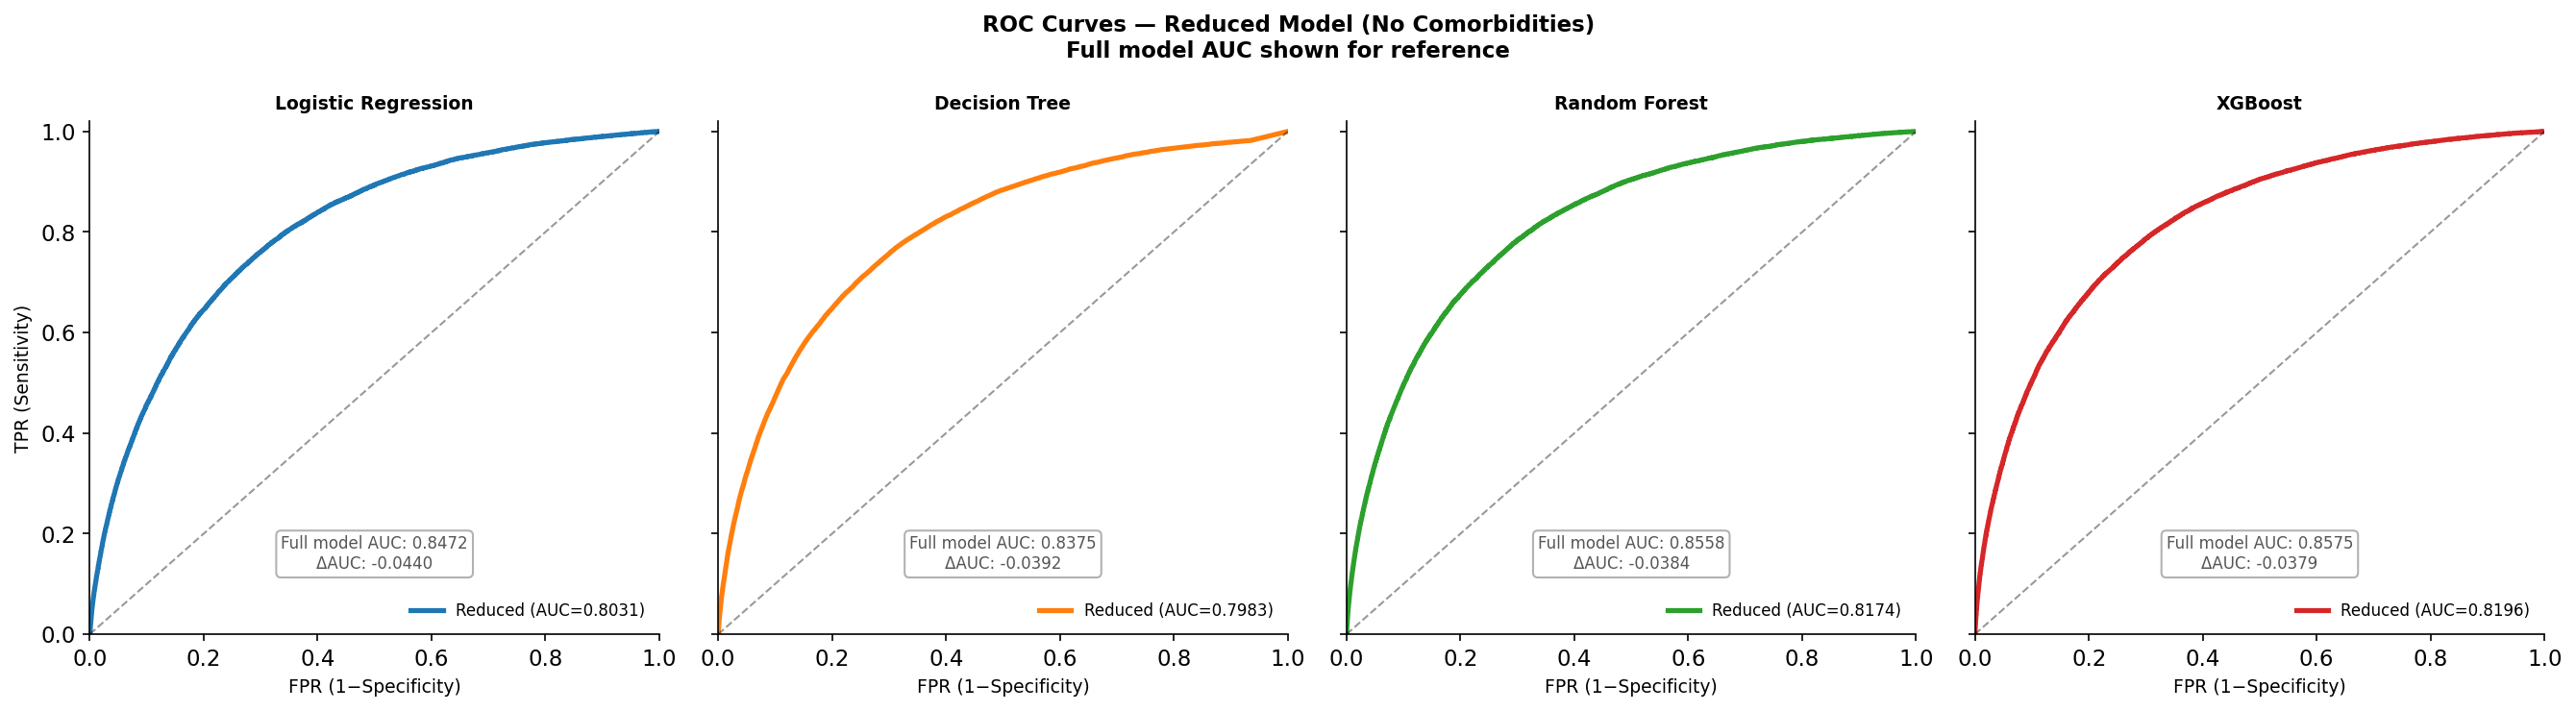

Saved fig10_reduced_roc.png


In [10]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5), sharey=True)

for ax, name in zip(axes, MODELS_REDUCED.keys()):
    color = MODEL_COLORS[name]

    # Full model curves — re-derive from pooled CV (reload fold CSVs aren't
    # enough; we need the raw probabilities stored in notebook 03's CURVES dict)
    # Instead recompute pooled AUC from the summary and draw approximate curves
    # using the reduced model's y_true (same folds, same labels).

    # Reduced model curve
    y_true_r, y_prob_r = CURVES_REDUCED[name]
    fpr_r, tpr_r, _ = roc_curve(y_true_r, y_prob_r)
    auc_r = roc_auc_score(y_true_r, y_prob_r)

    ax.plot(fpr_r, tpr_r, lw=2.5, color=color, label=f'Reduced (AUC={auc_r:.4f})')

    # Full model AUC annotation (actual curve not stored — show as text)
    full_auc = BASELINE_AUC[name]
    delta = auc_r - full_auc
    ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.4)
    ax.set_title(name, fontsize=9, fontweight='bold')
    ax.set_xlabel('FPR (1−Specificity)', fontsize=9)
    if ax == axes[0]:
        ax.set_ylabel('TPR (Sensitivity)', fontsize=9)
    ax.legend(frameon=False, fontsize=8, loc='lower right')

    ax.text(0.5, 0.12,
            f'Full model AUC: {full_auc:.4f}\nΔAUC: {delta:+.4f}',
            transform=ax.transAxes, ha='center', va='bottom',
            fontsize=8, color='#555',
            bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='#aaa', alpha=0.9))

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1.02)

plt.suptitle('ROC Curves — Reduced Model (No Comorbidities)\n'
             'Full model AUC shown for reference',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig10_reduced_roc.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved fig10_reduced_roc.png')

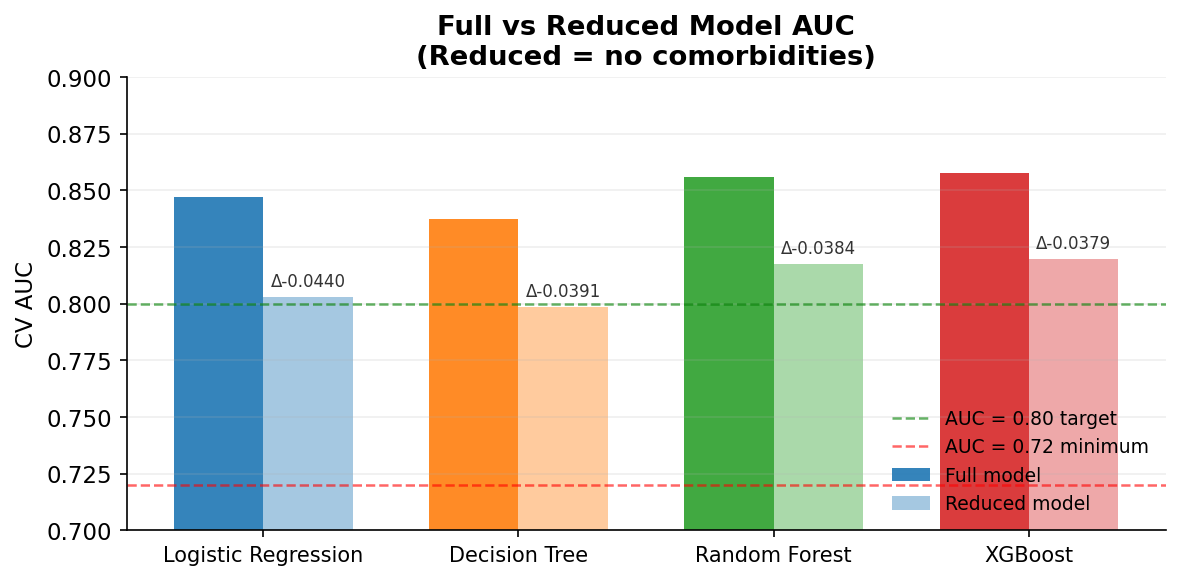

Saved fig11_reduced_auc_comparison.png


In [11]:
fig, ax = plt.subplots(figsize=(8, 4))

models  = comparison_df['Model'].tolist()
x       = np.arange(len(models))
w       = 0.35

bars_full = ax.bar(x - w/2, comparison_df['Full AUC'],    w,
                   color=[MODEL_COLORS[m] for m in models],
                   alpha=0.9, label='Full model')
bars_red  = ax.bar(x + w/2, comparison_df['Reduced AUC'], w,
                   color=[MODEL_COLORS[m] for m in models],
                   alpha=0.4, label='Reduced model')

# Annotate delta
for i, (_, r) in enumerate(comparison_df.iterrows()):
    ax.annotate(f'Δ{r["ΔAUC"]:+.4f}',
                xy=(i + w/2, r['Reduced AUC']),
                xytext=(0, 5), textcoords='offset points',
                ha='center', fontsize=8, color='#333')

ax.axhline(0.80, color='green', ls='--', lw=1.2, alpha=0.6, label='AUC = 0.80 target')
ax.axhline(0.72, color='red',   ls='--', lw=1.2, alpha=0.6, label='AUC = 0.72 minimum')
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=10)
ax.set_ylabel('CV AUC')
ax.set_ylim(0.70, 0.90)
ax.set_title('Full vs Reduced Model AUC\n(Reduced = no comorbidities)',
             fontweight='bold')
ax.legend(frameon=False, fontsize=9, loc='lower right')
ax.grid(axis='y', alpha=0.2)

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig11_reduced_auc_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved fig11_reduced_auc_comparison.png')

In [12]:
print('Fitting final reduced models on full BRFSS 2022...\n')

FINAL_REDUCED = make_models(
    make_preprocessors(ORDINAL_REDUCED, BINARY_REDUCED)[0],  # tree
    make_preprocessors(ORDINAL_REDUCED, BINARY_REDUCED)[1],  # lr
)

for name, pipeline in FINAL_REDUCED.items():
    t0 = time.time()
    pipeline.fit(X_train_reduced, y_train)
    print(f'  {name}: {time.time()-t0:.1f}s')

print('\nFinal reduced models fitted.')

Fitting final reduced models on full BRFSS 2022...

  Logistic Regression: 4.4s
  Decision Tree: 1.6s
  Random Forest: 8.8s
  XGBoost: 2.4s

Final reduced models fitted.


In [13]:
VAR_LABELS = {
    'INCOME3'  : 'Household income',
    'EDUCA'    : 'Education',
    'SEXVAR'   : 'Sex',
    '_AGEG5YR' : 'Age group',
    '_IMPRACE' : 'Race/ethnicity',
    'EMPLOY1'  : 'Employment status',
    'MARITAL'  : 'Marital status',
    '_URBSTAT' : 'Urban/Rural',
    '_SMOKER3' : 'Smoking status',
    '_BMI5CAT' : 'BMI category',
    'PERSDOC3' : 'Has personal doctor',
    'CHECKUP1' : 'Last checkup',
    'EXERANY2' : 'Any exercise',
    'DRNKANY6' : 'Any alcohol',
    'HLTHPLN2' : 'Health insurance',
    'MEDCOST1' : 'Cost barrier',
}

FEATURE_NAMES_REDUCED = ORDINAL_REDUCED + BINARY_REDUCED

importance_dfs_red = {}
income_ranks = {'full': {}, 'reduced': {}}

for name, pipeline in FINAL_REDUCED.items():
    clf = pipeline.named_steps['clf']
    if name == 'Logistic Regression':
        importances = np.abs(clf.coef_[0])
    else:
        importances = clf.feature_importances_

    imp_df = pd.DataFrame({
        'feature'    : FEATURE_NAMES_REDUCED,
        'importance' : importances,
    }).sort_values('importance', ascending=False)
    imp_df['importance_norm'] = imp_df['importance'] / imp_df['importance'].sum()

    importance_dfs_red[name] = imp_df
    income_ranks['reduced'][name] = list(imp_df['feature']).index('INCOME3') + 1

    fname = name.lower().replace(' ', '_')
    imp_df.to_csv(TABLE_DIR / f'feature_importance_reduced_{fname}.csv', index=False)

# Load full model income ranks from notebook 03 CSVs
for name in MODELS_REDUCED.keys():
    fname = name.lower().replace(' ', '_')
    full_imp = pd.read_csv(TABLE_DIR / f'feature_importance_{fname}.csv')
    income_ranks['full'][name] = list(full_imp['feature']).index('INCOME3') + 1

print('=== INCOME RANK: FULL vs REDUCED ===\n')
print(f'{"Model":<22}  {"Full rank":>10}  {"Reduced rank":>14}  {"Change":>8}')
print('-' * 58)
for name in MODELS_REDUCED.keys():
    fr = income_ranks['full'][name]
    rr = income_ranks['reduced'][name]
    print(f'{name:<22}  {fr:>10}  {rr:>14}  {rr-fr:>+8}')

print()
print('When comorbidities are removed, income typically rises in rank.')
print('This is expected — comorbidities absorb income variance in the full model.')

=== INCOME RANK: FULL vs REDUCED ===

Model                    Full rank    Reduced rank    Change
----------------------------------------------------------
Logistic Regression             13               7        -6
Decision Tree                    6               5        -1
Random Forest                    6               4        -2
XGBoost                         11               6        -5

When comorbidities are removed, income typically rises in rank.
This is expected — comorbidities absorb income variance in the full model.


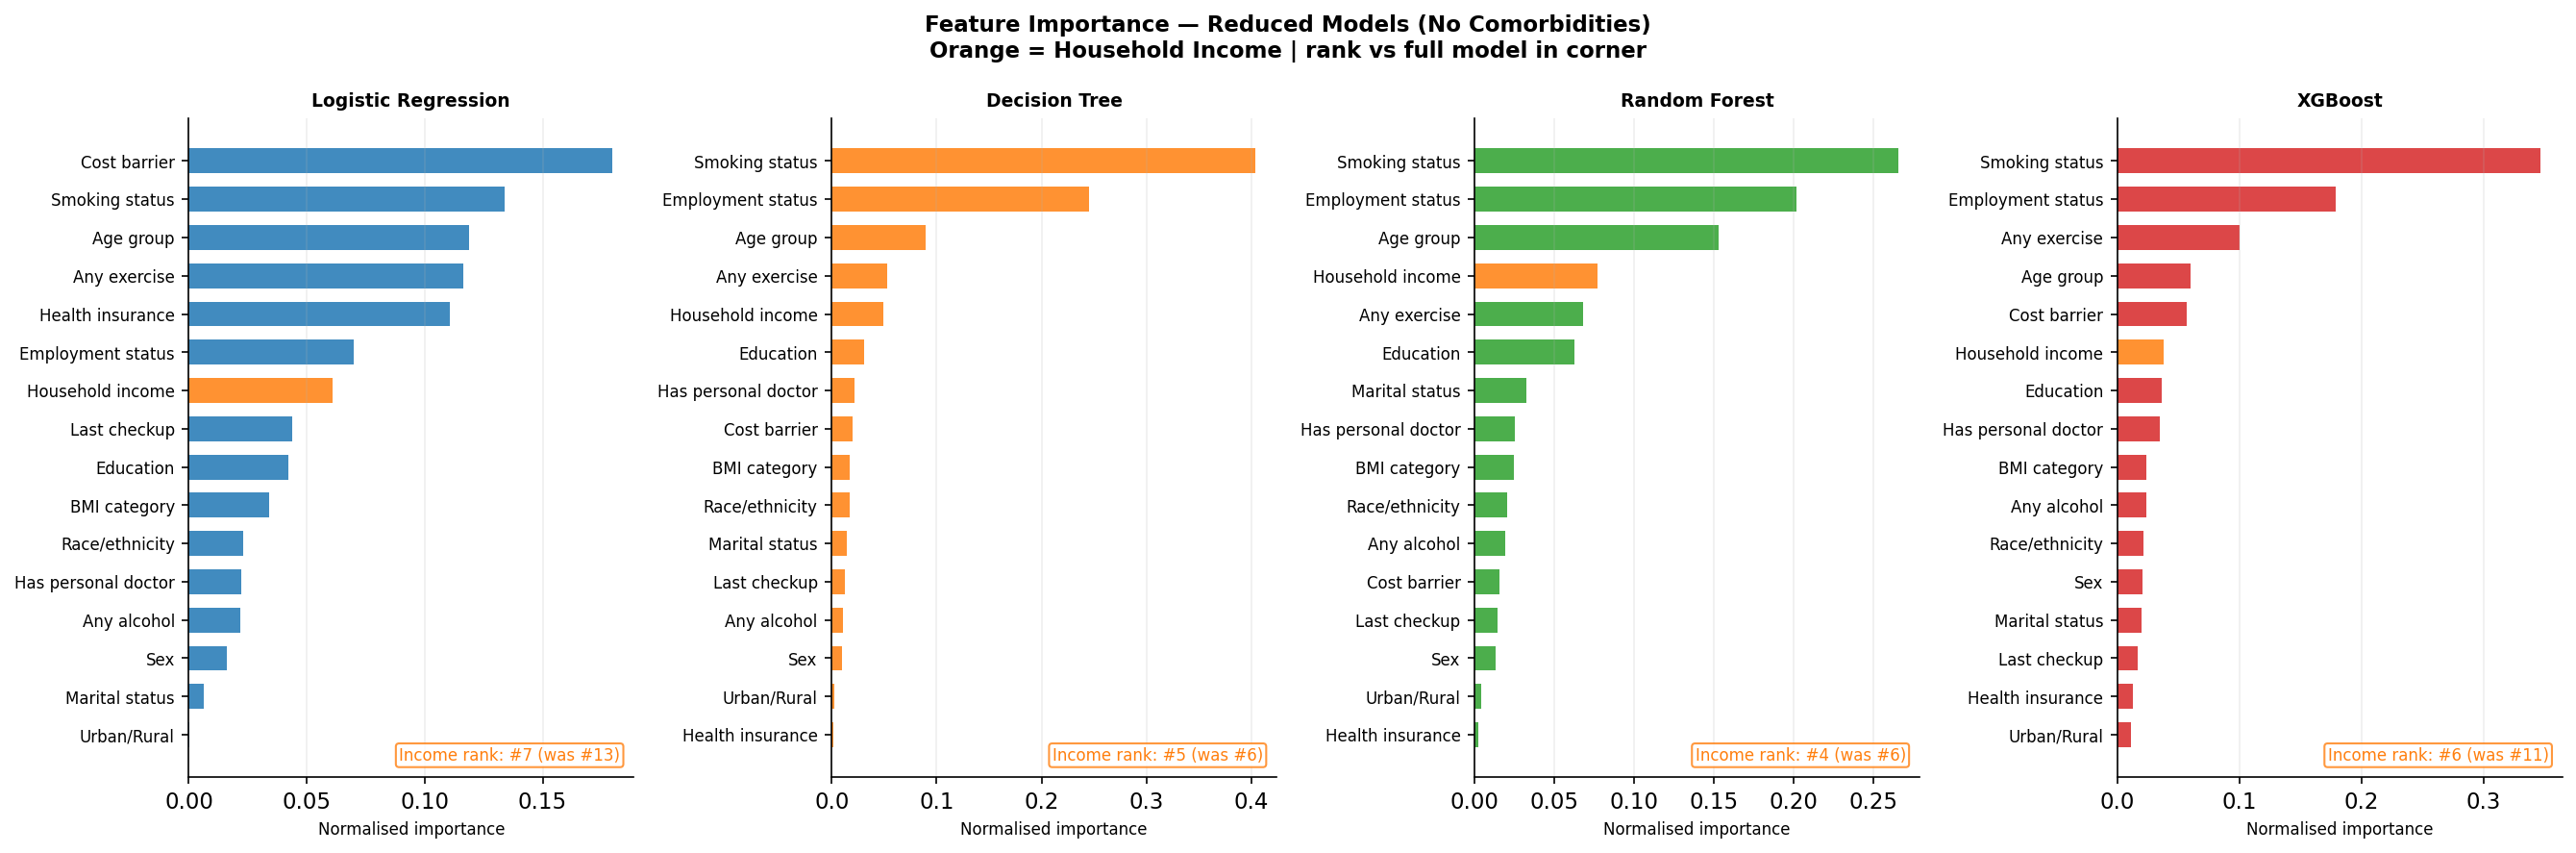

Saved fig12_reduced_feature_importance.png


In [14]:
fig, axes = plt.subplots(1, 4, figsize=(18, 6), sharey=False)

for ax, (name, imp_df) in zip(axes, importance_dfs_red.items()):
    colors = [MODEL_COLORS[name] if f != 'INCOME3' else '#FF7F0E'
              for f in imp_df['feature']]
    ax.barh(range(len(imp_df)), imp_df['importance_norm'],
            color=colors, alpha=0.85, height=0.65)
    ax.set_yticks(range(len(imp_df)))
    ax.set_yticklabels([VAR_LABELS.get(f, f) for f in imp_df['feature']],
                       fontsize=8)
    ax.set_title(name, fontsize=9, fontweight='bold')
    ax.set_xlabel('Normalised importance', fontsize=8)
    ax.invert_yaxis()
    ax.grid(axis='x', alpha=0.2)

    income_rank = income_ranks['reduced'][name]
    full_rank   = income_ranks['full'][name]
    ax.text(0.97, 0.02,
            f'Income rank: #{income_rank} (was #{full_rank})',
            transform=ax.transAxes, ha='right', va='bottom', fontsize=8,
            color='#FF7F0E',
            bbox=dict(boxstyle='round,pad=0.2', fc='white',
                      ec='#FF7F0E', alpha=0.8))

plt.suptitle('Feature Importance — Reduced Models (No Comorbidities)\n'
             'Orange = Household Income | rank vs full model in corner',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig12_reduced_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved fig12_reduced_feature_importance.png')

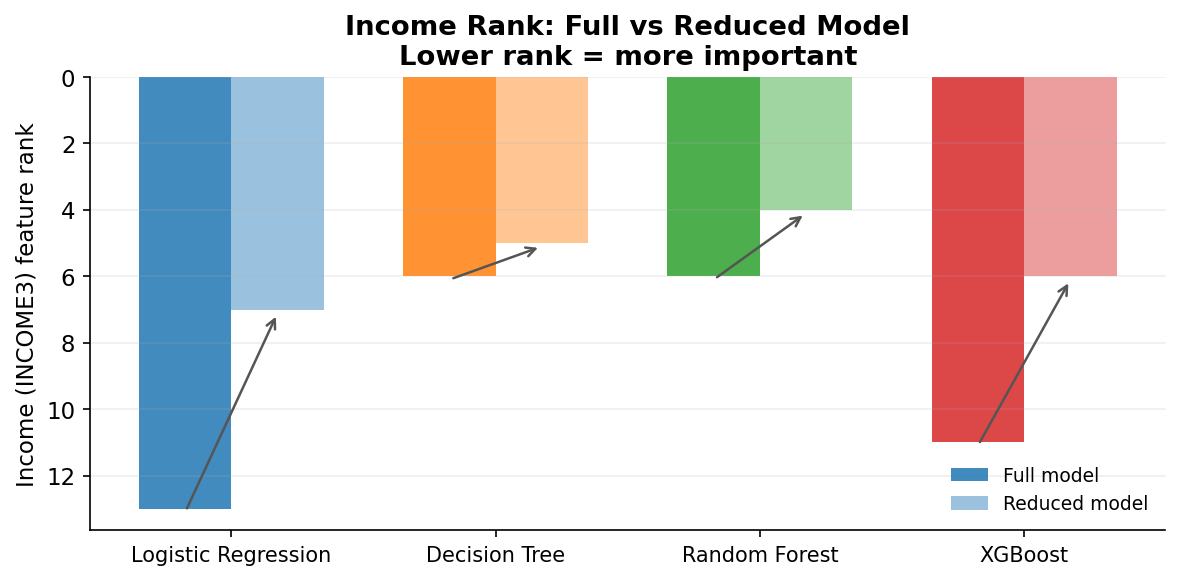

Saved fig13_income_rank_shift.png


In [15]:
# Visualise how income rank changes between full and reduced model
# across all 4 algorithms. This directly supports the H2 narrative.

fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(MODELS_REDUCED))
w = 0.35

full_ranks    = [income_ranks['full'][n]    for n in MODELS_REDUCED]
reduced_ranks = [income_ranks['reduced'][n] for n in MODELS_REDUCED]

ax.bar(x - w/2, full_ranks,    w, label='Full model',    alpha=0.85,
       color=[MODEL_COLORS[n] for n in MODELS_REDUCED])
ax.bar(x + w/2, reduced_ranks, w, label='Reduced model', alpha=0.45,
       color=[MODEL_COLORS[n] for n in MODELS_REDUCED])

for i, (fr, rr) in enumerate(zip(full_ranks, reduced_ranks)):
    ax.annotate('', xy=(i + w/2, rr + 0.1), xytext=(i - w/2, fr + 0.1),
                arrowprops=dict(arrowstyle='->', color='#555', lw=1.2))

ax.set_xticks(x)
ax.set_xticklabels(list(MODELS_REDUCED.keys()), fontsize=10)
ax.set_ylabel('Income (INCOME3) feature rank')
ax.set_title('Income Rank: Full vs Reduced Model\n'
             'Lower rank = more important', fontweight='bold')
ax.invert_yaxis()
ax.legend(frameon=False, fontsize=9)
ax.grid(axis='y', alpha=0.2)

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig13_income_rank_shift.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved fig13_income_rank_shift.png')

In [16]:
# ── Save reduced model results ────────────────────────────────────────
reduced_summary_rows = []
for name, fold_df in CV_REDUCED.items():
    reduced_summary_rows.append({
        'Model'           : name,
        'AUC'             : fold_df['auc'].mean(),
        'AUC_std'         : fold_df['auc'].std(),
        'Sensitivity'     : fold_df['sensitivity'].mean(),
        'Sensitivity_std' : fold_df['sensitivity'].std(),
        'Specificity'     : fold_df['specificity'].mean(),
        'Specificity_std' : fold_df['specificity'].std(),
        'F1'              : fold_df['f1'].mean(),
        'F1_std'          : fold_df['f1'].std(),
        'AP'              : fold_df['ap'].mean(),
        'AP_std'          : fold_df['ap'].std(),
        'Brier'           : fold_df['brier'].mean(),
        'Brier_std'       : fold_df['brier'].std(),
        'n_features'      : len(REDUCED_FEATURES),
    })

reduced_summary_df = pd.DataFrame(reduced_summary_rows)
reduced_summary_df.to_csv(TABLE_DIR / 'reduced_model_results.csv', index=False)

print('=== NOTEBOOK 04 SUMMARY ===\n')
print(f'Reduced feature set : {len(REDUCED_FEATURES)} features '
      f'(dropped {len(COMORBIDITY_FEATURES)} comorbidity variables)')
print()
print(f'{"Model":<22}  {"Red. AUC":>10}  {"Full AUC":>10}  {"ΔAUC":>8}')
print('-' * 55)
for _, r in comparison_df.iterrows():
    viable = '✓' if abs(r['ΔAUC']) < 0.03 else ('~' if abs(r['ΔAUC']) < 0.05 else '✗')
    print(f'{r["Model"]:<22}  {r["Reduced AUC"]:>10.4f}  '
          f'{r["Full AUC"]:>10.4f}  {r["ΔAUC"]:>+8.4f}  {viable}')

print()
print('Income rank in reduced model:')
for name in MODELS_REDUCED:
    fr = income_ranks['full'][name]
    rr = income_ranks['reduced'][name]
    print(f'  {name:<22} #{rr} (full model: #{fr})')

print()
print('Saved:')
print('  reduced_model_results.csv')
print('  reduced_model_comparison.csv')
print('  feature_importance_reduced_[model].csv  (×4)')
print()
print('Next: notebooks/05_income_pathway.ipynb')    

=== NOTEBOOK 04 SUMMARY ===

Reduced feature set : 16 features (dropped 8 comorbidity variables)

Model                     Red. AUC    Full AUC      ΔAUC
-------------------------------------------------------
Logistic Regression         0.8032      0.8472   -0.0440  ~
Decision Tree               0.7984      0.8375   -0.0391  ~
Random Forest               0.8174      0.8558   -0.0384  ~
XGBoost                     0.8196      0.8575   -0.0379  ~

Income rank in reduced model:
  Logistic Regression    #7 (full model: #13)
  Decision Tree          #5 (full model: #6)
  Random Forest          #4 (full model: #6)
  XGBoost                #6 (full model: #11)

Saved:
  reduced_model_results.csv
  reduced_model_comparison.csv
  feature_importance_reduced_[model].csv  (×4)

Next: notebooks/05_income_pathway.ipynb
